# Лабораторная работа 1. Линейная регрессия и факторный анализ (PCA)

**Цель:** изучение основ линейной регрессии, построение моделей (линейная, Lasso, Ridge),
оценка качества и снижение размерности методом PCA.

**Датасет:** [Boston Housing](https://www.kaggle.com/datasets/schirmerchad/bostonhoustingmlnd)
(`schirmerchad/bostonhoustingmlnd`)

## 1. Импорт библиотек и загрузка данных

In [1]:
import warnings
from pathlib import Path

import kagglehub
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.linear_model import Lasso, LinearRegression, Ridge
from sklearn.metrics import mean_absolute_percentage_error, mean_squared_error, r2_score
from sklearn.model_selection import KFold, cross_val_score, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from statsmodels.stats.outliers_influence import variance_inflation_factor

warnings.filterwarnings("ignore")

RANDOM_STATE = 42
TEST_SIZE = 0.2
CV_FOLDS = 5

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (10, 6)

path = kagglehub.dataset_download("schirmerchad/bostonhoustingmlnd")
df = pd.read_csv(Path(path) / "housing.csv")

print(f"Путь к данным: {path}")
print(f"Размер: {df.shape}")
df.head()

Путь к данным: C:\Users\soroc\.cache\kagglehub\datasets\schirmerchad\bostonhoustingmlnd\versions\1
Размер: (489, 4)


,RM,LSTAT,PTRATIO,MEDV
0,6.575,4.98,15.3,504000.0
1,6.421,9.14,17.8,453600.0
2,7.185,4.03,17.8,728700.0
3,6.998,2.94,18.7,701400.0
4,7.147,5.33,18.7,760200.0


**Пояснение.** Датасет загружен через `kagglehub` из репозитория
`schirmerchad/bostonhoustingmlnd`. Файл `housing.csv` содержит **489 объектов** и
**4 столбца**: три независимых признака (`RM`, `LSTAT`, `PTRATIO`) и целевую переменную
`MEDV` — медианную стоимость жилья в долларах. Целевая переменная **непрерывная**,
поэтому далее используются модели линейной регрессии (не логистической).
Первые строки таблицы показывают, что все поля числовые и масштабы признаков заметно
различаются (комнаты ~6, статус ~5–10, цена сотни тысяч) — позже потребуется стандартизация.

### Описание признаков

| Признак | Описание |
|---------|----------|
| **RM** | Среднее число комнат в жилище |
| **LSTAT** | Доля населения с низким социальным статусом, % |
| **PTRATIO** | Соотношение числа учеников и учителей в районе |
| **MEDV** | Медианная стоимость жилья, $ (**целевая переменная**) |

In [2]:
print(df.describe())
print("\nПропуски:\n", df.isnull().sum())
print("\nТипы:\n", df.dtypes)

               RM       LSTAT     PTRATIO          MEDV
count  489.000000  489.000000  489.000000  4.890000e+02
mean     6.240288   12.939632   18.516564  4.543429e+05
std      0.643650    7.081990    2.111268  1.653403e+05
min      3.561000    1.980000   12.600000  1.050000e+05
25%      5.880000    7.370000   17.400000  3.507000e+05
50%      6.185000   11.690000   19.100000  4.389000e+05
75%      6.575000   17.120000   20.200000  5.187000e+05
max      8.398000   37.970000   22.000000  1.024800e+06

Пропуски:
 RM         0
LSTAT      0
PTRATIO    0
MEDV       0
dtype: int64

Типы:
 RM         float64
LSTAT      float64
PTRATIO    float64
MEDV       float64
dtype: object


**Пояснение.** По описательной статистике:
- средняя цена жилья (`MEDV`) ≈ **454 тыс. $**, разброс большой (от 105 тыс. до ≈1 млн);
- `RM` варьируется примерно от 3.6 до 8.4 комнат;
- `LSTAT` — от ≈2% до ≈38%, распределение, судя по квартилям, асимметрично;
- пропущенных значений **нет** (все счётчики нулевые), типы — `float64`.
Это упрощает предобработку: удалять/заполнять пропуски и кодировать категории не нужно.

## 2. Визуализация распределений

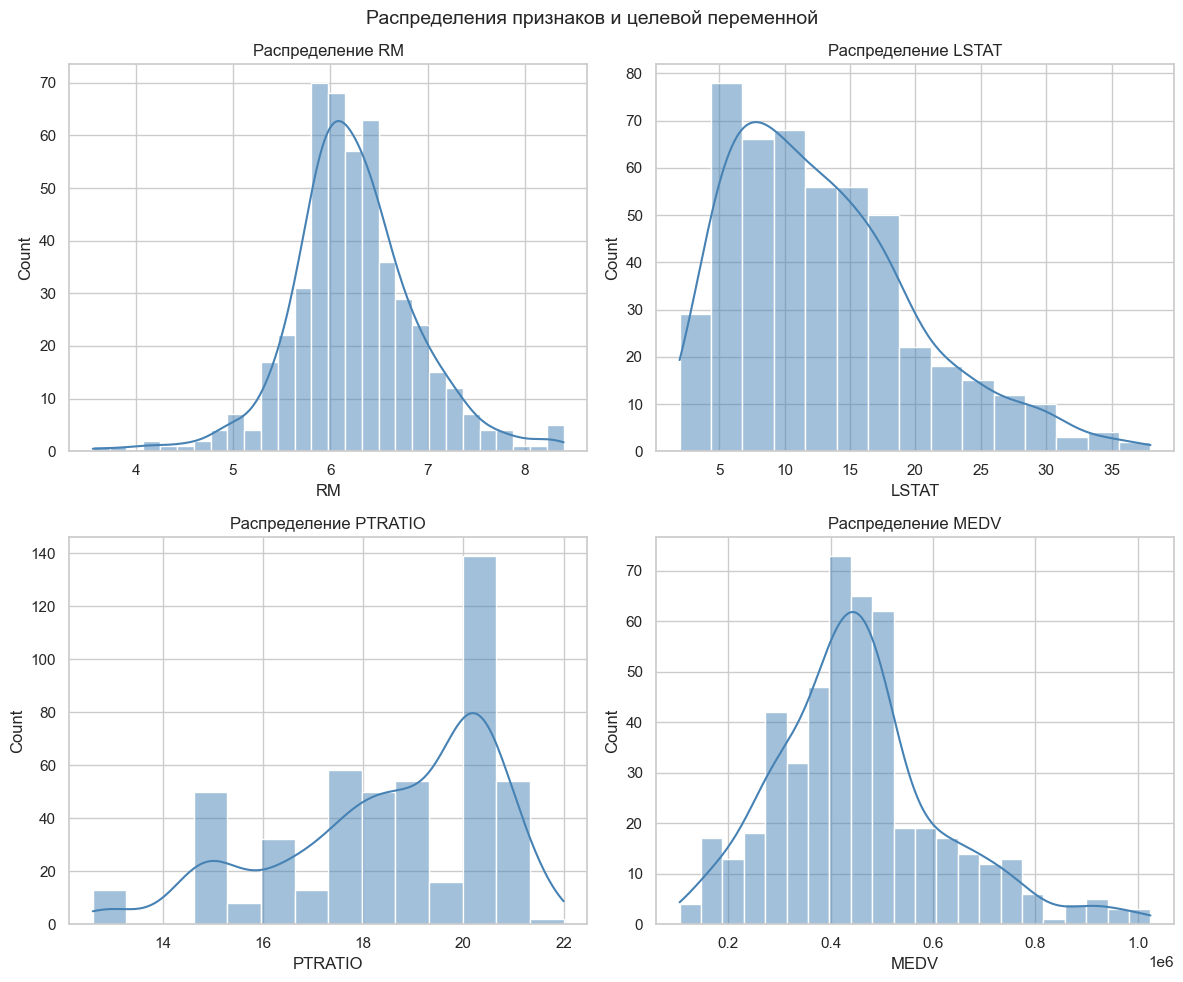

In [3]:
features = ["RM", "LSTAT", "PTRATIO"]
target = "MEDV"

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
for ax, col in zip(axes.flat, features + [target]):
    sns.histplot(df[col], kde=True, ax=ax, color="steelblue")
    ax.set_title(f"Распределение {col}")
fig.suptitle("Распределения признаков и целевой переменной", fontsize=14)
plt.tight_layout()
plt.show()

**Пояснение к графикам распределений.**
- `RM` и `PTRATIO` выглядят относительно симметрично, близко к колоколообразной форме.
- `LSTAT` имеет **правый хвост**: районы с высокой долей населения низкого статуса встречаются реже,
  но сильно влияют на разброс.
- `MEDV` тоже асимметричен: больше наблюдений в среднем ценовом диапазоне, дорогие дома — реже.
Для линейной регрессии асимметрия не запрещена, но может увеличивать ошибку на «хвостах»
(очень дешёвые/дорогие объекты).

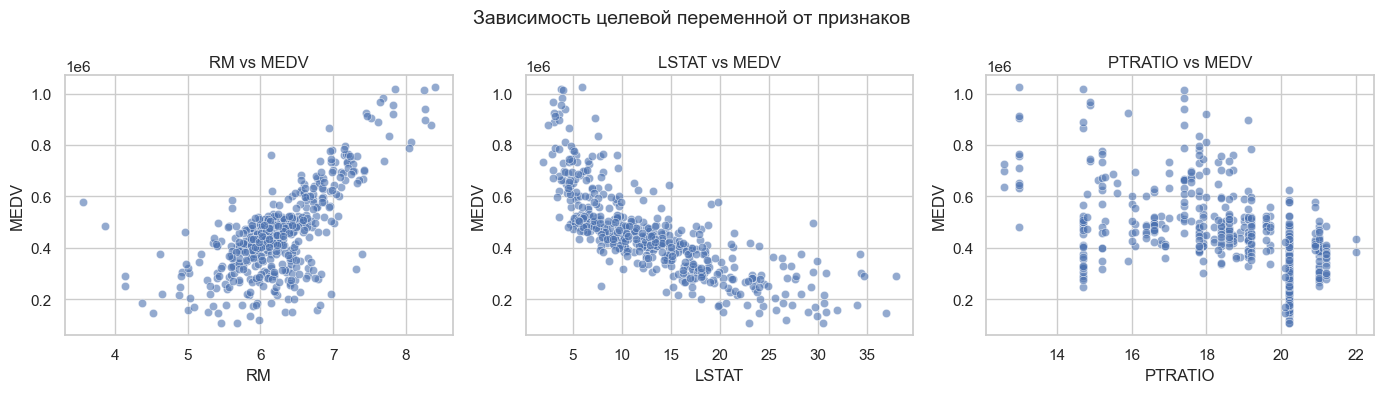

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, col in zip(axes, features):
    sns.scatterplot(data=df, x=col, y=target, ax=ax, alpha=0.6)
    ax.set_title(f"{col} vs {target}")
fig.suptitle("Зависимость целевой переменной от признаков", fontsize=14)
plt.tight_layout()
plt.show()

**Пояснение к зависимостям признак–цель.**
- С ростом `RM` (больше комнат) цена `MEDV` в среднем **растёт** — положительная связь.
- С ростом `LSTAT` цена **падает** — сильная отрицательная зависимость, точки укладываются
  почти в нисходящий тренд.
- `PTRATIO` связан с ценой слабее и отрицательно: выше нагрузка на учителя — ниже цена района.
Связи выглядят преимущественно **линейными**, что обосновывает выбор линейных моделей.
Небольшой «веер» разброса на концах говорит, что residual variance не полностью постоянна.

## 3. Предобработка данных

In [5]:
df_clean = df.dropna().copy()
print(f"После удаления пропусков: {df_clean.shape[0]} (было {df.shape[0]})")
print("Категориальных признаков нет — кодирование не требуется.")

X = df_clean[features]
y = df_clean[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, random_state=RANDOM_STATE
)
print(f"Train: {X_train.shape[0]} (80%), Test: {X_test.shape[0]} (20%)")

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
print("Стандартизация: StandardScaler (fit на train, transform на test).")

После удаления пропусков: 489 (было 489)
Категориальных признаков нет — кодирование не требуется.
Train: 391 (80%), Test: 98 (20%)
Стандартизация: StandardScaler (fit на train, transform на test).


**Пояснение по предобработке.**
1. `dropna()` оставлен для полноты пайплайна; размер выборки не изменился (489 → 489).
2. Категориальных столбцов нет — One-Hot / Label Encoding не нужны.
3. Разбиение **80/20** (`train_test_split`, `random_state=42`) даёт 391 объект для обучения
   и 98 для независимого теста — оценка обобщающей способности.
4. `StandardScaler` приводит признаки к нулевому среднему и единичной дисперсии.
   `fit` выполняется **только на train**, чтобы не было утечки информации из теста.
   Стандартизация важна для Lasso/Ridge (штраф чувствителен к масштабу) и **обязательна перед PCA**.

## 4. Матрица корреляций и VIF

,RM,LSTAT,PTRATIO,MEDV
RM,1.000,-0.612,-0.305,0.697
LSTAT,-0.612,1.000,0.360,-0.761
PTRATIO,-0.305,0.360,1.000,-0.519
MEDV,0.697,-0.761,-0.519,1.000


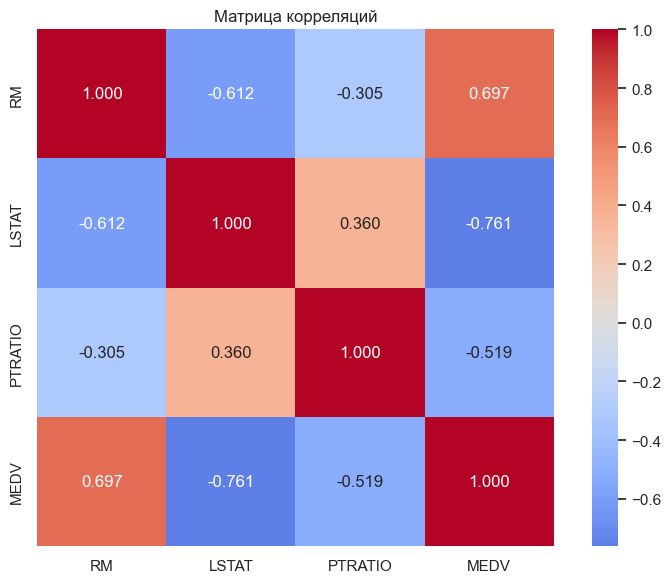

In [6]:
corr = df_clean.corr()
display(corr.round(3))

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap="coolwarm", center=0, fmt=".3f", square=True)
plt.title("Матрица корреляций")
plt.tight_layout()
plt.show()

**Пояснение к матрице корреляций.**
- С `MEDV` сильнее всего связан `LSTAT` (**−0.76**, отрицательно) и `RM` (**+0.70**, положительно);
  `PTRATIO` коррелирует слабее (**−0.52**).
- Между предикторами есть умеренная связь `RM`–`LSTAT` (**−0.61**): больше комнат чаще
  встречается в районах с меньшим `LSTAT`. Это потенциальный источник мультиколлинеарности,
  поэтому далее считаем коэффициент **VIF**.
- Высокая корреляция предиктора с целью — хороший знак для линейной модели;
  высокая корреляция *между* предикторами — риск неустойчивых коэффициентов.

In [7]:
X_all_scaled = StandardScaler().fit_transform(X)
vif_data = pd.DataFrame({
    "Признак": features,
    "VIF": [variance_inflation_factor(X_all_scaled, i) for i in range(X_all_scaled.shape[1])],
})
display(vif_data)

print(f"max VIF = {vif_data['VIF'].max():.3f}")
print("Правило: VIF > 5–10 указывает на мультиколлинеарность.")
print("Вывод: сильной мультиколлинеарности нет (все VIF < 2).")

,Признак,VIF
0,RM,1.619920
1,LSTAT,1.689112
2,PTRATIO,1.164402


max VIF = 1.689
Правило: VIF > 5–10 указывает на мультиколлинеарность.
Вывод: сильной мультиколлинеарности нет (все VIF < 2).


**Пояснение по VIF.**
VIF (Variance Inflation Factor) показывает, насколько дисперсия коэффициента признака
раздута из‑за линейной зависимости с остальными предикторами.
Обычно считают: VIF < 5 — приемлемо, VIF > 5–10 — проблема мультиколлинеарности.

В нашем случае все VIF **меньше 2** (максимум у `LSTAT` ≈ 1.69). Значит, сильной
мультиколлинеарности **нет**, коэффициенты линейной регрессии должны быть относительно
устойчивы. Тем не менее PCA всё равно применим: он гарантирует ортогональность компонент
и позволяет снизить размерность (3 → 2).

## 5. Регрессия на исходных признаках

Обучаем **LinearRegression**, **Lasso** и **Ridge**.
Разбиение 80/20, 5-fold кросс-валидация. Метрики качества: **RMSE**, **R²**, **MAPE**.

In [8]:
def evaluate(y_true, y_pred, name=""):
    return {
        "Модель": name,
        "RMSE": float(np.sqrt(mean_squared_error(y_true, y_pred))),
        "R2": float(r2_score(y_true, y_pred)),
        "MAPE_%": float(mean_absolute_percentage_error(y_true, y_pred) * 100),
    }

def cv_scores(pipeline, X_data, y_data):
    kf = KFold(n_splits=CV_FOLDS, shuffle=True, random_state=RANDOM_STATE)
    neg_mse = cross_val_score(pipeline, X_data, y_data, cv=kf, scoring="neg_mean_squared_error")
    r2 = cross_val_score(pipeline, X_data, y_data, cv=kf, scoring="r2")
    return {
        "CV_RMSE": float(np.sqrt(-neg_mse.mean())),
        "CV_RMSE_std": float(np.sqrt(-neg_mse).std()),
        "CV_R2": float(r2.mean()),
        "CV_R2_std": float(r2.std()),
    }

def fit_and_score(model, name, X_tr, X_te, y_tr, y_te, X_full, y_full):
    pipe = Pipeline([("scaler", StandardScaler()), ("model", model)])
    pipe.fit(X_tr, y_tr)
    y_pred = pipe.predict(X_te)
    metrics = evaluate(y_te, y_pred, name)
    metrics.update(cv_scores(pipe, X_full, y_full))
    return metrics, y_pred

models = {
    "Линейная": LinearRegression(),
    "Lasso": Lasso(alpha=1000.0, random_state=RANDOM_STATE, max_iter=10000),
    "Гребневая (Ridge)": Ridge(alpha=1.0, random_state=RANDOM_STATE),
}

results_raw, preds_raw = [], {}
for name, model in models.items():
    metrics, y_pred = fit_and_score(model, name, X_train, X_test, y_train, y_test, X, y)
    results_raw.append(metrics)
    preds_raw[name] = y_pred

df_raw = pd.DataFrame(results_raw)
display(df_raw.round(4))

,Модель,RMSE,R2,MAPE_%,CV_RMSE,CV_RMSE_std,CV_R2,CV_R2_std
0,Линейная,82395.5433,0.6911,18.0502,89164.4211,7350.1825,0.7046,0.0376
1,Lasso,82497.3950,0.6903,18.0919,89174.6232,7279.4941,0.7046,0.0366
2,Гребневая (Ridge),82413.1610,0.6910,18.0556,89158.4057,7345.5726,0.7046,0.0375


**Пояснение к метрикам на исходных признаках.**
- **RMSE** — корень из средней квадратичной ошибки (в тех же единицах, что цена, $);
  чем меньше, тем лучше.
- **R²** — доля объяснённой дисперсии целевой переменной; чем ближе к 1, тем лучше.
- **MAPE** — средняя абсолютная процентная ошибка; удобна для относительной интерпретации.

Ожидаемый порядок величин: R² ≈ **0.69**, MAPE ≈ **18%**, RMSE ≈ **82–83 тыс. $**.
Обычная линейная регрессия, Lasso и Ridge дают **почти одинаковое** качество:
признаков мало, мультиколлинеарность слабая, поэтому регуляризация почти не меняет результат.
CV-метрики близки к тестовым → сильного переобучения не видно.

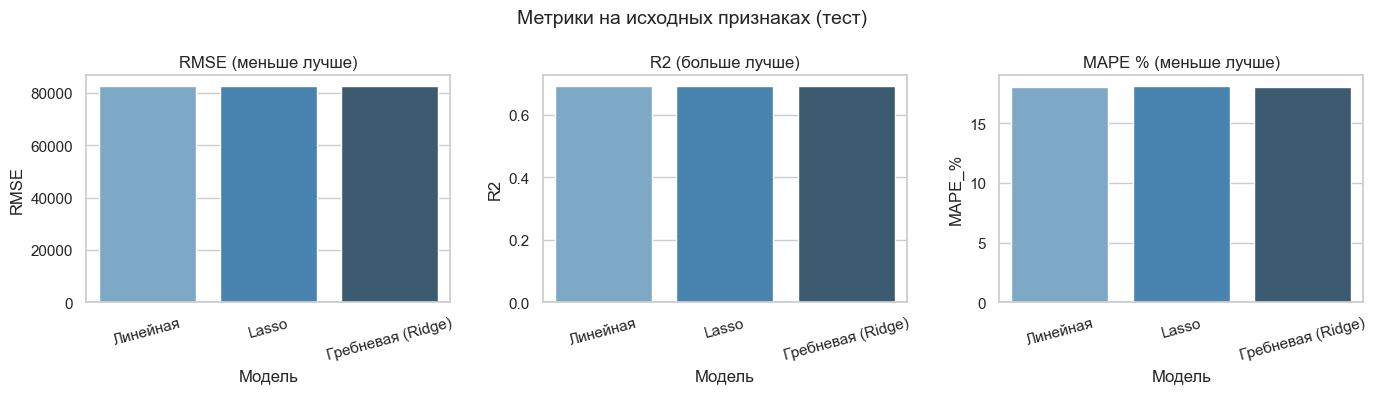

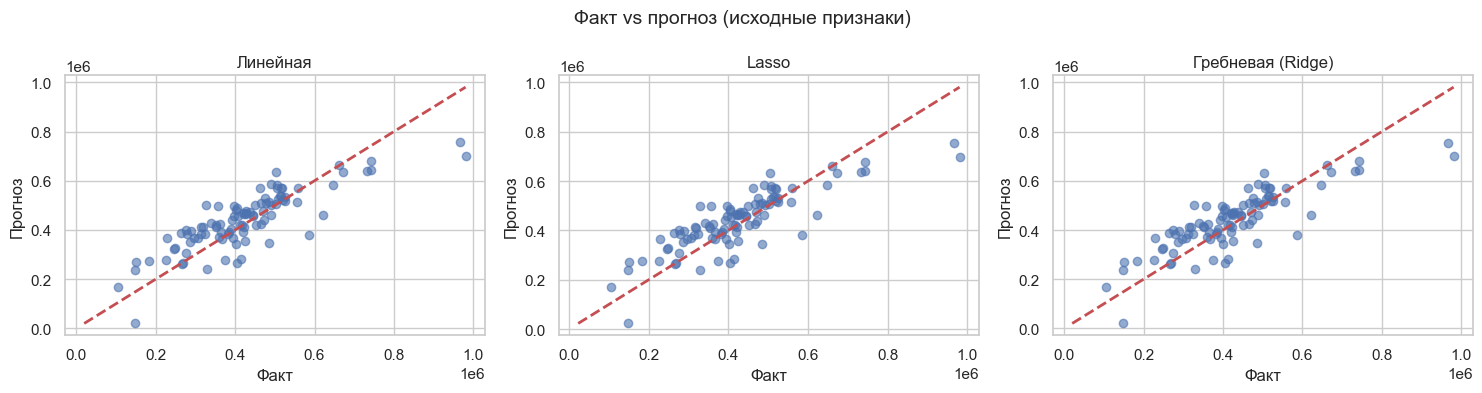

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, metric, title in zip(
    axes, ["RMSE", "R2", "MAPE_%"],
    ["RMSE (меньше лучше)", "R2 (больше лучше)", "MAPE % (меньше лучше)"],
):
    sns.barplot(data=df_raw, x="Модель", y=metric, ax=ax, hue="Модель", legend=False, palette="Blues_d")
    ax.set_title(title)
    ax.tick_params(axis="x", rotation=15)
fig.suptitle("Метрики на исходных признаках (тест)", fontsize=14)
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, (name, y_pred) in zip(axes, preds_raw.items()):
    ax.scatter(y_test, y_pred, alpha=0.6)
    lims = [min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())]
    ax.plot(lims, lims, "r--", lw=2)
    ax.set_xlabel("Факт")
    ax.set_ylabel("Прогноз")
    ax.set_title(name)
fig.suptitle("Факт vs прогноз (исходные признаки)", fontsize=14)
plt.tight_layout()
plt.show()

**Пояснение к графикам качества.**
Столбчатые диаграммы показывают, что столбцы RMSE / R² / MAPE у трёх моделей почти
одинаковой высоты — визуально подтверждается близость результатов.

На графиках «факт vs прогноз» идеальные предсказания лежали бы на красной пунктирной
диагонали. Точки группируются вдоль неё, но на высоких ценах разброс больше:
модель чаще **занижает** самые дорогие объекты. Это типично для линейной модели
на асимметричной целевой переменной и объясняет ненулевой MAPE (~18%).

## 6. PCA: стандартизация и снижение размерности

PC1: 62.90%, накопленно: 62.90%
PC2: 24.48%, накопленно: 87.38%
PC3: 12.62%, накопленно: 100.00%


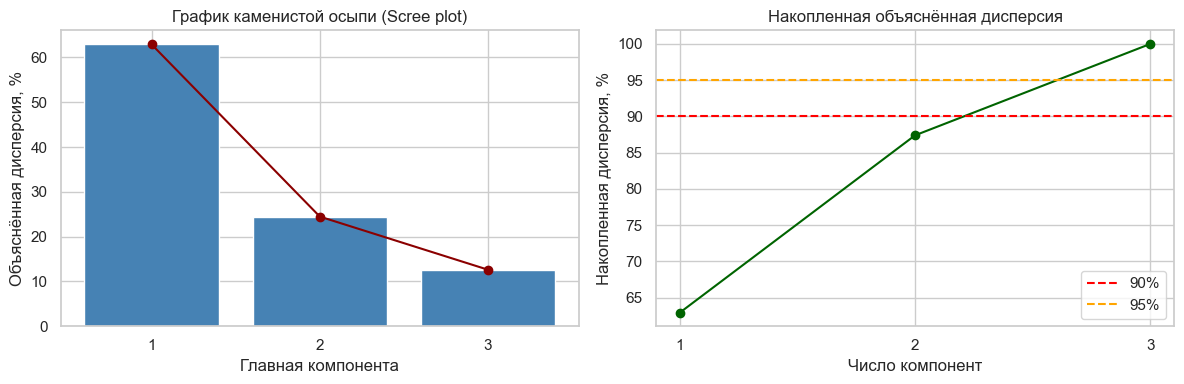

In [10]:
pca_full = PCA()
pca_full.fit(X_train_scaled)
explained = pca_full.explained_variance_ratio_
cumsum = np.cumsum(explained)

for i, (ev, cs) in enumerate(zip(explained, cumsum), 1):
    print(f"PC{i}: {ev*100:.2f}%, накопленно: {cs*100:.2f}%")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].bar(range(1, len(explained)+1), explained*100, color="steelblue")
axes[0].plot(range(1, len(explained)+1), explained*100, "o-", color="darkred")
axes[0].set_xlabel("Главная компонента")
axes[0].set_ylabel("Объяснённая дисперсия, %")
axes[0].set_title("График каменистой осыпи (Scree plot)")
axes[0].set_xticks(range(1, len(explained)+1))

axes[1].plot(range(1, len(cumsum)+1), cumsum*100, "o-", color="darkgreen")
axes[1].axhline(90, color="red", linestyle="--", label="90%")
axes[1].axhline(95, color="orange", linestyle="--", label="95%")
axes[1].set_xlabel("Число компонент")
axes[1].set_ylabel("Накопленная дисперсия, %")
axes[1].set_title("Накопленная объяснённая дисперсия")
axes[1].legend()
axes[1].set_xticks(range(1, len(cumsum)+1))
plt.tight_layout()
plt.show()

**Пояснение к графику каменистой осыпи (scree plot).**
PCA выполнен на **уже стандартизованных** признаках train-выборки.
- PC1 объясняет ≈ **63%** дисперсии, PC2 ≈ **24%**, PC3 ≈ **13%**.
- Накопленно две компоненты дают ≈ **87%** информации; три — 100%.
- На scree plot после второй компоненты «ступень» становится ниже — это аргумент
  выбрать **k = 2** (реальное снижение размерности 3 → 2).
- Для формального порога 95% пришлось бы оставить все 3 компоненты, и тогда PCA
  не уменьшал бы число признаков, а только ортогонализировал их.

In [11]:
# По scree plot берём 2 компоненты (~87% дисперсии): снижение размерности 3 -> 2
n_components = 2
print(f"Выбрано компонент: {n_components}")
print(f"Объясняют: {cumsum[n_components-1]*100:.2f}% дисперсии")

pca = PCA(n_components=n_components)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

vif_pca = pd.DataFrame({
    "Компонента": [f"PC{i}" for i in range(1, n_components+1)],
    "VIF": [variance_inflation_factor(X_train_pca, i) for i in range(n_components)],
})
print("\nVIF после PCA (ожидаем 1.0 — ортогональность):")
display(vif_pca)

loadings = pd.DataFrame(
    pca.components_.T,
    columns=[f"PC{i}" for i in range(1, n_components+1)],
    index=features,
)
print("Нагрузки главных компонент:")
display(loadings.round(3))

Выбрано компонент: 2
Объясняют: 87.38% дисперсии

VIF после PCA (ожидаем 1.0 — ортогональность):


,Компонента,VIF
0,PC1,1.0
1,PC2,1.0


Нагрузки главных компонент:


,PC1,PC2
RM,-0.610,0.410
LSTAT,0.628,-0.271
PTRATIO,0.483,0.871


**Пояснение к преобразованию PCA.**
Оставляем 2 главные компоненты. `fit` PCA — на train, `transform` — на train и test
(без утечки). После преобразования:
- **VIF(PC1) = VIF(PC2) = 1.0** — компоненты ортогональны, мультиколлинеарность устранена
  по построению метода.
- По матрице нагрузок: PC1 в основном смешивает `RM` (отрицательно) и `LSTAT`/`PTRATIO`
  (положительно) — «ось социально-жилищного контраста»; PC2 сильнее связан с `PTRATIO`.
Потеря ≈13% дисперсии — плата за сжатие; её влияние на точность модели проверим ниже.

## 7. Регрессия на главных компонентах

In [12]:
def fit_and_score_pca(model, name, X_tr, X_te, y_tr, y_te, y_full):
    model.fit(X_tr, y_tr)
    y_pred = model.predict(X_te)
    metrics = evaluate(y_te, y_pred, name)
    pipe = Pipeline([
        ("scaler", StandardScaler()),
        ("pca", PCA(n_components=n_components)),
        ("model", type(model)(**model.get_params())),
    ])
    metrics.update(cv_scores(pipe, X, y_full))
    return metrics, y_pred

models_pca = {
    "Линейная": LinearRegression(),
    "Lasso": Lasso(alpha=1000.0, random_state=RANDOM_STATE, max_iter=10000),
    "Гребневая (Ridge)": Ridge(alpha=1.0, random_state=RANDOM_STATE),
}

results_pca, preds_pca = [], {}
for name, model in models_pca.items():
    metrics, y_pred = fit_and_score_pca(
        model, name, X_train_pca, X_test_pca, y_train, y_test, y
    )
    results_pca.append(metrics)
    preds_pca[name] = y_pred

df_pca = pd.DataFrame(results_pca)
display(df_pca.round(4))

,Модель,RMSE,R2,MAPE_%,CV_RMSE,CV_RMSE_std,CV_R2,CV_R2_std
0,Линейная,83024.2040,0.6864,18.3213,88851.1388,7993.1914,0.7066,0.0431
1,Lasso,83106.3048,0.6857,18.3083,88854.2316,7956.9195,0.7066,0.0427
2,Гребневая (Ridge),83043.0018,0.6862,18.3270,88849.8507,7985.8082,0.7067,0.0430


**Пояснение к метрикам на главных компонентах.**
Те же три модели обучены на PC1–PC2 вместо исходных `RM`/`LSTAT`/`PTRATIO`.
Для честной CV в пайплайн входят Scaler → PCA → модель (пересчёт на каждом фолде).

Ожидаемо тестовые метрики **чуть хуже**, чем на исходных признаках
(R² ≈ 0.686 против ≈ 0.691, MAPE ≈ 18.3% против ≈ 18.05%): мы отбросили часть дисперсии.
При этом модели снова почти не отличаются друг от друга. На кросс-валидации R² может быть
даже немного выше — сжатие иногда стабилизирует оценку, хотя на конкретном тесте чуть проигрывает.

## 8. Сравнение метрик: исходные признаки vs PCA

,Вариант,Модель,RMSE,R2,MAPE_%,CV_RMSE,CV_R2
0,Исходные признаки,Линейная,82395.5433,0.6911,18.0502,89164.4211,0.7046
1,Исходные признаки,Lasso,82497.3950,0.6903,18.0919,89174.6232,0.7046
2,Исходные признаки,Гребневая (Ridge),82413.1610,0.6910,18.0556,89158.4057,0.7046
3,Главные компоненты,Линейная,83024.2040,0.6864,18.3213,88851.1388,0.7066
4,Главные компоненты,Lasso,83106.3048,0.6857,18.3083,88854.2316,0.7066
5,Главные компоненты,Гребневая (Ridge),83043.0018,0.6862,18.3270,88849.8507,0.7067


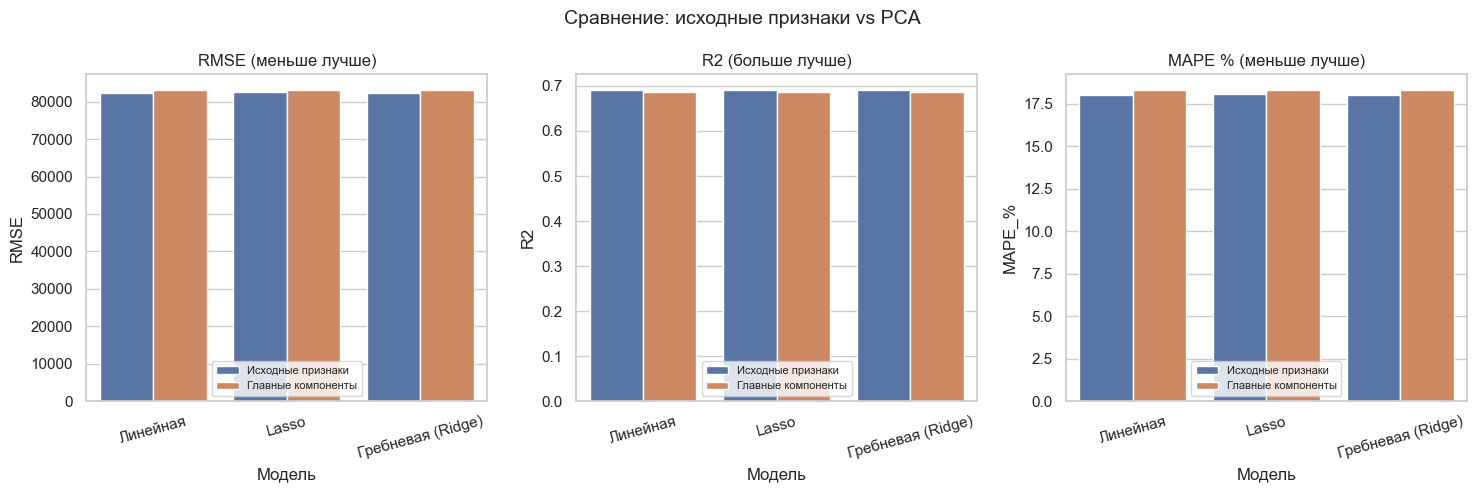

In [13]:
df_raw["Вариант"] = "Исходные признаки"
df_pca["Вариант"] = "Главные компоненты"
df_cmp = pd.concat([df_raw, df_pca], ignore_index=True)
display(df_cmp[["Вариант", "Модель", "RMSE", "R2", "MAPE_%", "CV_RMSE", "CV_R2"]].round(4))

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, metric, title in zip(
    axes, ["RMSE", "R2", "MAPE_%"],
    ["RMSE (меньше лучше)", "R2 (больше лучше)", "MAPE % (меньше лучше)"],
):
    sns.barplot(data=df_cmp, x="Модель", y=metric, hue="Вариант", ax=ax)
    ax.set_title(title)
    ax.tick_params(axis="x", rotation=15)
    ax.legend(fontsize=8)
fig.suptitle("Сравнение: исходные признаки vs PCA", fontsize=14)
plt.tight_layout()
plt.show()

**Пояснение к сравнению.**
Сводная таблица и парные столбцы показывают:
- на **тесте** исходные признаки чуть лучше по RMSE, R² и MAPE;
- разница небольшая (порядка долей процента по R² / MAPE) — PCA с 2 компонентами
  сохранил основную полезную информацию;
- PCA выполнил свою роль по заданию: мультиколлинеарность устранена (VIF = 1),
  размерность снижена, качество practically сопоставимо.

Если бы признаков было десятки и корреляции были сильными, выигрыш PCA / регуляризации
был бы заметнее. Здесь признаков всего три и VIF изначально низкий, поэтому эффект мягкий.

## 9. Выводы

1. Лучшая модель на исходных признаках — **линейная регрессия**
   (Test R² ≈ 0.691, RMSE ≈ 82396, MAPE ≈ 18.05%).
2. Lasso и Ridge дают почти те же метрики: признаков мало, мультиколлинеарность слабая (VIF < 2).
3. PCA с 2 компонентами устраняет корреляцию признаков (VIF = 1), но тестовые метрики
   чуть хуже из‑за потери ~13% дисперсии.
4. На кросс-валидации PCA иногда чуть стабильнее (CV R² ≈ 0.707 vs 0.705) —
   типичный компромисс «сжатие / точность».
5. Улучшить модель можно: нелинейные признаки (полиномы), подбор `alpha` для Lasso/Ridge,
   расширение набора признаков.